In [8]:
import pandas as pd
from autogluon.tabular import TabularPredictor
from autogluon.tabular import TabularDataset
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:

# 讀取資料
all_train_data = pd.read_csv(rf'C:\Users\E4-159\Documents\py_surr\imbd2025\初\final_combined_data.csv')

# 準備特徵與目標
X = all_train_data.drop(columns=['Time', 'Disp. X', 'Disp. Z', '日期'])
y_x = all_train_data['Disp. X']

# 合併特徵與目標，AutoGluon 需要一個 DataFrame
train_data = X.copy()
train_data['Disp. X'] = y_x

# 訓練 AutoGluon TabularPredictor
predictor = TabularPredictor(label='Disp. X', problem_type='regression', eval_metric='mse').fit(
    train_data,
    time_limit=600,  # 訓練時間上限（秒）
    presets='best_quality'
)

# 顯示最佳模型與評分
leaderboard = predictor.leaderboard(silent=True)
print(leaderboard)

# 預測（以訓練集為例）
preds = predictor.predict(X)
print(preds.head())

No path specified. Models will be saved in: "AutogluonModels\ag-20250819_051252"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.3.0
Python Version:     3.12.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          20
Memory Avail:       11.14 GB / 31.72 GB (35.1%)
Disk Space Avail:   327.15 GB / 930.07 GB (35.2%)
Presets specified: ['best_quality']
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluon will be fit on subsets of the data. Then holdo

(_ray_fit pid=41016) [1000]	valid_set's l2: 1.70882
(_ray_fit pid=41016) [4000]	valid_set's l2: 0.94374 [repeated 24x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)
(_ray_fit pid=41016) [7000]	valid_set's l2: 0.820459 [repeated 23x across cluster]
(_ray_fit pid=41016) [10000]	valid_set's l2: 0.766506 [repeated 24x across cluster]


(_dystack pid=25576) 	-0.7522	 = Validation score   (-mean_squared_error)
(_dystack pid=25576) 	24.55s	 = Training   runtime
(_dystack pid=25576) 	29.4s	 = Validation runtime
(_dystack pid=25576) Fitting model: LightGBM_BAG_L1 ... Training model for up to 61.19s of the 108.40s of remaining time.
(_dystack pid=25576) 	Fitting 8 child models (S1F1 - S1F8) | Fitting with ParallelLocalFoldFittingStrategy (8 workers, per: cpus=2, gpus=0, memory=0.41%)


(_ray_fit pid=36564) [1000]	valid_set's l2: 1.00734 [repeated 9x across cluster]
(_ray_fit pid=40476) [4000]	valid_set's l2: 0.854476 [repeated 24x across cluster]
(_ray_fit pid=40476) [7000]	valid_set's l2: 0.830531 [repeated 23x across cluster]
(_ray_fit pid=40476) [10000]	valid_set's l2: 0.823428 [repeated 21x across cluster]


(_dystack pid=25576) 	-0.8899	 = Validation score   (-mean_squared_error)
(_dystack pid=25576) 	19.94s	 = Training   runtime
(_dystack pid=25576) 	25.9s	 = Validation runtime
(_dystack pid=25576) Fitting model: RandomForestMSE_BAG_L1 ... Training model for up to 35.33s of the 82.54s of remaining time.
(_dystack pid=25576) c:\Users\E4-159\anaconda3\envs\autogluon\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
(_dystack pid=25576)   warnings.warn(
(_dystack pid=25576) 	-0.9514	 = Validation score   (-mean_squared_error)
(_dystack pid=25576) 	3.71s	 = Training   runtime
(_dystack pid=25576) 	0.63s	 = Validation runtime
(_dystack pid=25576) Fitting model: CatBoost_BAG_L1 ... Training model for up to 30.71s of the 77.91s of remaining time.
(_dystack pid=25576) 	Fitting 8 child 

(_ray_fit pid=27772) [1000]	valid_set's l2: 0.570097 [repeated 7x across cluster]
(_ray_fit pid=30056) [4000]	valid_set's l2: 0.488069 [repeated 17x across cluster]


(_dystack pid=25576) 	-0.5815	 = Validation score   (-mean_squared_error)
(_dystack pid=25576) 	10.38s	 = Training   runtime
(_dystack pid=25576) 	1.36s	 = Validation runtime
(_dystack pid=25576) Fitting model: LightGBM_BAG_L2 ... Training model for up to 31.18s of the 31.16s of remaining time.
(_ray_fit pid=33224) 	Ran out of time, stopping training early. (Stopping on epoch 0) [repeated 7x across cluster]
(_dystack pid=25576) 	Fitting 8 child models (S1F1 - S1F8) | Fitting with ParallelLocalFoldFittingStrategy (8 workers, per: cpus=2, gpus=0, memory=0.46%)
(_dystack pid=25576) 	-0.5341	 = Validation score   (-mean_squared_error)
(_dystack pid=25576) 	1.33s	 = Training   runtime
(_dystack pid=25576) 	0.07s	 = Validation runtime
(_dystack pid=25576) Fitting model: RandomForestMSE_BAG_L2 ... Training model for up to 28.32s of the 28.30s of remaining time.
(_dystack pid=25576) c:\Users\E4-159\anaconda3\envs\autogluon\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._v

                     model  score_val         eval_metric  pred_time_val  \
0      WeightedEnsemble_L3  -0.442617  mean_squared_error      69.774832   
1      WeightedEnsemble_L2  -0.443476  mean_squared_error      41.014101   
2     ExtraTreesMSE_BAG_L1  -0.457562  mean_squared_error       0.561424   
3          LightGBM_BAG_L2  -0.496020  mean_squared_error      69.151210   
4     ExtraTreesMSE_BAG_L2  -0.499964  mean_squared_error      69.774329   
5   NeuralNetFastAI_BAG_L2  -0.510308  mean_squared_error      69.304983   
6   RandomForestMSE_BAG_L2  -0.515615  mean_squared_error      69.771797   
7    KNeighborsDist_BAG_L1  -0.530553  mean_squared_error       0.224405   
8           XGBoost_BAG_L2  -0.561698  mean_squared_error      69.172434   
9        LightGBMXT_BAG_L2  -0.562359  mean_squared_error      70.699551   
10   KNeighborsUnif_BAG_L1  -0.562797  mean_squared_error       0.219851   
11         CatBoost_BAG_L2  -0.595360  mean_squared_error      69.122794   
12         C

In [3]:
# 報表
report = predictor.fit_summary()
print(report)

*** Summary of fit() ***
Estimated performance of each model:
                     model  score_val         eval_metric  pred_time_val    fit_time  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0      WeightedEnsemble_L3  -0.442617  mean_squared_error      69.774832  271.087624                0.000503           0.101659            3       True         21
1      WeightedEnsemble_L2  -0.443476  mean_squared_error      41.014101  168.010768                0.001011           0.063314            2       True         12
2     ExtraTreesMSE_BAG_L1  -0.457562  mean_squared_error       0.561424    1.437701                0.561424           1.437701            1       True          7
3          LightGBM_BAG_L2  -0.496020  mean_squared_error      69.151210  270.371410                0.058781           1.831025            2       True         14
4     ExtraTreesMSE_BAG_L2  -0.499964  mean_squared_error      69.774329  270.985965                0.681901           2.44

c:\Users\E4-159\anaconda3\envs\autogluon\Lib\site-packages\autogluon\core\utils\plots.py:169: UserWarning: AutoGluon summary plots cannot be created because bokeh is not installed. To see plots, please do: "pip install bokeh==2.0.1"
  warnings.warn('AutoGluon summary plots cannot be created because bokeh is not installed. To see plots, please do: "pip install bokeh==2.0.1"')


In [4]:
all_train_data = pd.read_csv(rf'C:\Users\E4-159\Documents\py_surr\imbd2025\初\final_combined_data.csv')

# 準備特徵與目標
X = all_train_data.drop(columns=['Time', 'Disp. X', 'Disp. Z', '日期'])
y_z = all_train_data['Disp. Z']

# 合併特徵與目標，AutoGluon 需要一個 DataFrame
train_data = X.copy()
train_data['Disp. Z'] = y_z

# 訓練 AutoGluon TabularPredictor
predictor_z = TabularPredictor(label='Disp. Z', problem_type='regression', eval_metric='mse').fit(
    train_data,
    time_limit=600,  # 訓練時間上限（秒）
    presets='best_quality'
)

# 顯示最佳模型與評分
leaderboard_z = predictor_z.leaderboard(silent=True)
print(leaderboard_z)

# 預測（以訓練集為例）
preds_z = predictor_z.predict(X)
print(preds_z.head())

No path specified. Models will be saved in: "AutogluonModels\ag-20250819_052325"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.3.0
Python Version:     3.12.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          20
Memory Avail:       10.76 GB / 31.72 GB (33.9%)
Disk Space Avail:   323.66 GB / 930.07 GB (34.8%)
Presets specified: ['best_quality']
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluon will be fit on subsets of the data. Then holdo

                        model  score_val         eval_metric  pred_time_val  \
0         WeightedEnsemble_L2  -0.270507  mean_squared_error       3.828167   
1        ExtraTreesMSE_BAG_L1  -0.275520  mean_squared_error       0.545601   
2      RandomForestMSE_BAG_L1  -0.326565  mean_squared_error       0.542992   
3       KNeighborsDist_BAG_L1  -0.327661  mean_squared_error       0.243825   
4       KNeighborsUnif_BAG_L1  -0.354167  mean_squared_error       0.250968   
5              XGBoost_BAG_L1  -0.390098  mean_squared_error       3.038741   
6        CatBoost_r177_BAG_L1  -0.391850  mean_squared_error       0.039870   
7             CatBoost_BAG_L1  -0.393913  mean_squared_error       0.042200   
8           LightGBMXT_BAG_L1  -0.428968  mean_squared_error      37.377588   
9             LightGBM_BAG_L1  -0.520814  mean_squared_error      34.911800   
10       LightGBMLarge_BAG_L1  -0.620171  mean_squared_error       4.743652   
11     NeuralNetFastAI_BAG_L1  -1.128878  mean_squar

In [5]:
# 報表
report_z = predictor_z.fit_summary()
print(report_z)

*** Summary of fit() ***
Estimated performance of each model:
                        model  score_val         eval_metric  pred_time_val    fit_time  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0         WeightedEnsemble_L2  -0.270507  mean_squared_error       3.828167   30.243707                0.000000           0.084747            2       True         14
1        ExtraTreesMSE_BAG_L1  -0.275520  mean_squared_error       0.545601    1.351804                0.545601           1.351804            1       True          7
2      RandomForestMSE_BAG_L1  -0.326565  mean_squared_error       0.542992    3.142476                0.542992           3.142476            1       True          5
3       KNeighborsDist_BAG_L1  -0.327661  mean_squared_error       0.243825    0.022061                0.243825           0.022061            1       True          2
4       KNeighborsUnif_BAG_L1  -0.354167  mean_squared_error       0.250968    0.018561                0.250

c:\Users\E4-159\anaconda3\envs\autogluon\Lib\site-packages\autogluon\core\utils\plots.py:169: UserWarning: AutoGluon summary plots cannot be created because bokeh is not installed. To see plots, please do: "pip install bokeh==2.0.1"
  warnings.warn('AutoGluon summary plots cannot be created because bokeh is not installed. To see plots, please do: "pip install bokeh==2.0.1"')


In [25]:
def train(path,t=600):
    all_train_data = pd.read_csv(path)

    # 準備特徵與目標
    X = all_train_data.drop(columns=['Time', 'Disp. X', 'Disp. Z'])
    y_x = all_train_data['Disp. X']
    y_z = all_train_data['Disp. Z']

    # 合併特徵與目標，AutoGluon 需要一個 DataFrame
    train_data_x = X.copy()
    train_data_x['Disp. X'] = y_x

    train_data_z = X.copy()
    train_data_z['Disp. Z'] = y_z

    # 訓練 AutoGluon TabularPredictor
    predictor_x = TabularPredictor(label='Disp. X', problem_type='regression', eval_metric='mse').fit(
        train_data_x,
        time_limit=t,  # 訓練時間上限（秒）
        presets='best_quality',
    )

    predictor_z = TabularPredictor(label='Disp. Z', problem_type='regression', eval_metric='mse').fit(
        train_data_z,
        time_limit=t,  # 訓練時間上限（秒）
        presets='best_quality',
    )

    return predictor_x, predictor_z

def predict(predictor_x, predictor_z, X):
    y_x_gt = X['Disp. X']
    y_z_gt = X['Disp. Z']
    X = X.drop(columns=['Time', 'Disp. X', 'Disp. Z'])
    

    preds_x = predictor_x.predict(X)
    preds_z = predictor_z.predict(X)

    # mse ,rmse (mse+mse)**0.5
    mse_x = ((preds_x - y_x_gt) ** 2).mean()
    mse_z = ((preds_z - y_z_gt) ** 2).mean()
    rmse_x = mse_x ** 0.5
    rmse_z = mse_z ** 0.5
    print(f"RMSE for Disp. X: {rmse_x}")
    print(f"RMSE for Disp. Z: {rmse_z}")
    print(f"MSE for Disp. X: {mse_x}")
    print(f"MSE for Disp. Z: {mse_z}")
    print(f"RMSE for Disp. X + Z: {(mse_x + mse_z) ** 0.5}")

    #plot
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.scatter(y_x_gt, preds_x, alpha=0.5)
    plt.title('Predicted vs Actual for Disp. X')
    plt.xlabel('Actual Disp. X')
    plt.ylabel('Predicted Disp. X')
    plt.plot([y_x_gt.min(), y_x_gt.max()], [y_x_gt.min(), y_x_gt.max()], 'r--')
    plt.subplot(1, 2, 2)
    plt.scatter(y_z_gt, preds_z, alpha=0.5)
    plt.title('Predicted vs Actual for Disp. Z')
    plt.xlabel('Actual Disp. Z')
    plt.ylabel('Predicted Disp. Z')
    plt.plot([y_z_gt.min(), y_z_gt.max()], [y_z_gt.min(), y_z_gt.max()], 'r--')
    plt.tight_layout()
    plt.show()

    #plt.plot
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(y_x_gt, label='Actual Disp. X', color='blue')
    plt.plot(preds_x, label='Predicted Disp. X', color='orange')
    plt.title('Actual vs Predicted Disp. X')
    plt.xlabel('Index')
    plt.ylabel('Disp. X')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(y_z_gt, label='Actual Disp. Z', color='blue')
    plt.plot(preds_z, label='Predicted Disp. Z', color='orange')
    plt.title('Actual vs Predicted Disp. Z')
    plt.xlabel('Index')
    plt.ylabel('Disp. Z')
    plt.legend()
    plt.tight_layout()
    plt.show()
    return preds_x, preds_z, mse_x, mse_z, rmse_x, rmse_z

    

No path specified. Models will be saved in: "AutogluonModels\ag-20250819_092707"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.3.0
Python Version:     3.12.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          20
Memory Avail:       11.57 GB / 31.72 GB (36.5%)
Disk Space Avail:   254.54 GB / 930.07 GB (27.4%)
Presets specified: ['best_quality']
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluon will be fit on subsets of the data. Then holdo

RMSE for Disp. X: 16.2861370937326
RMSE for Disp. Z: 8.744175527374983
MSE for Disp. X: 265.2382614358529
MSE for Disp. Z: 76.46060565354355
RMSE for Disp. X + Z: 18.485098514462845


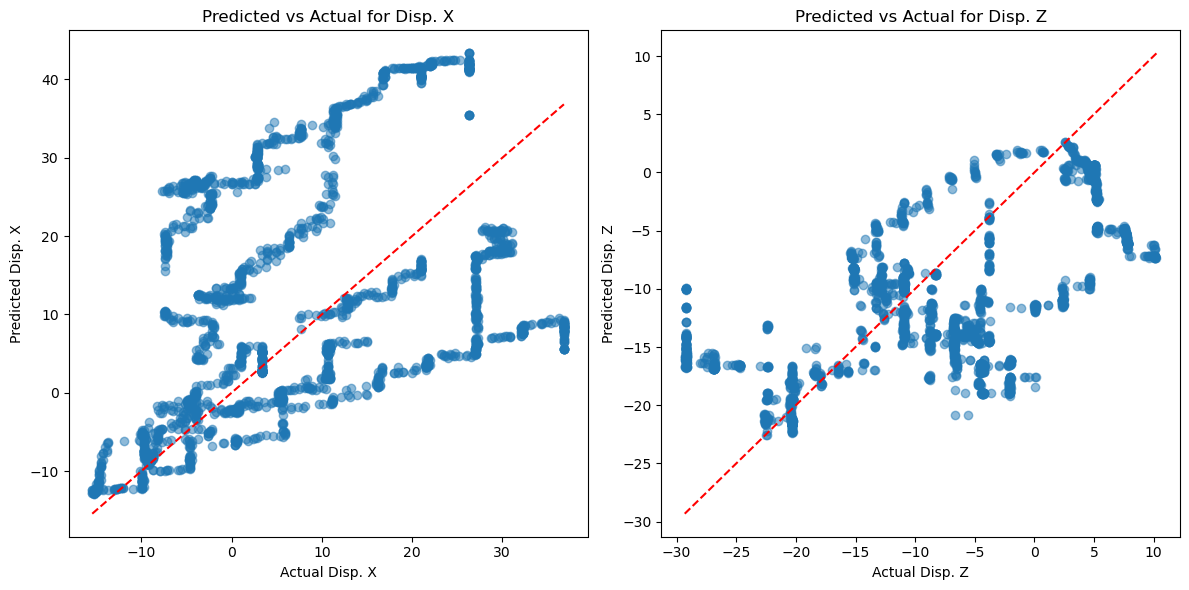

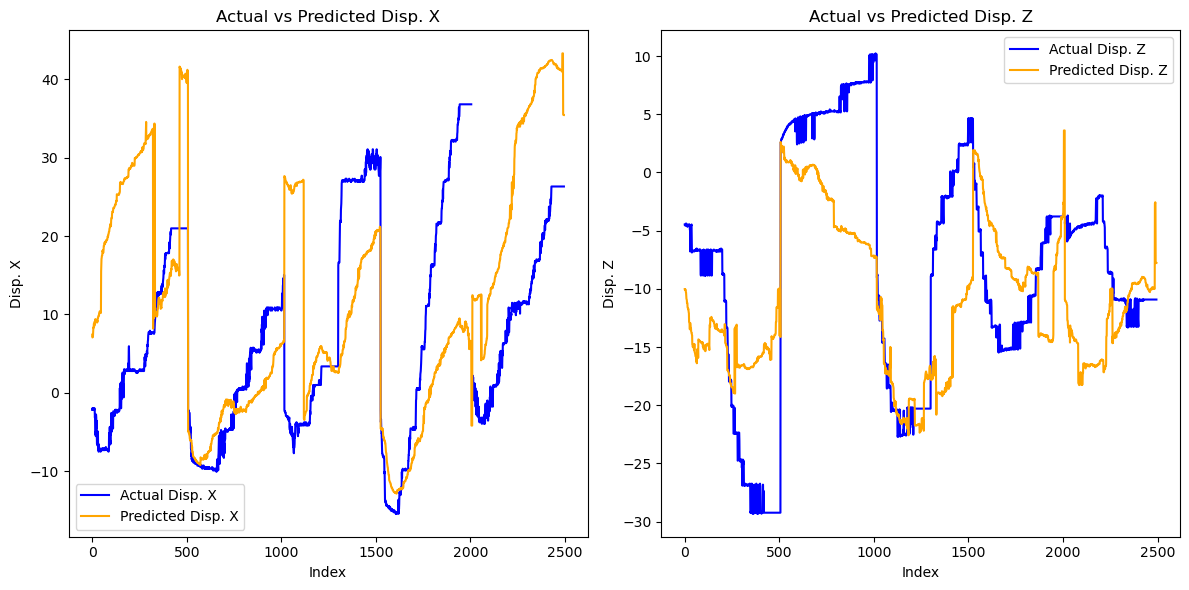

No path specified. Models will be saved in: "AutogluonModels\ag-20250819_093808"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.3.0
Python Version:     3.12.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          20
Memory Avail:       10.00 GB / 31.72 GB (31.5%)
Disk Space Avail:   252.39 GB / 930.07 GB (27.1%)
Presets specified: ['best_quality']
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluon will be fit on subsets of the data. Then holdo

RMSE for Disp. X: 16.462430816419364
RMSE for Disp. Z: 18.92348581639839
MSE for Disp. X: 271.01162838539386
MSE for Disp. Z: 358.0983154434311
RMSE for Disp. X + Z: 25.08206418596414


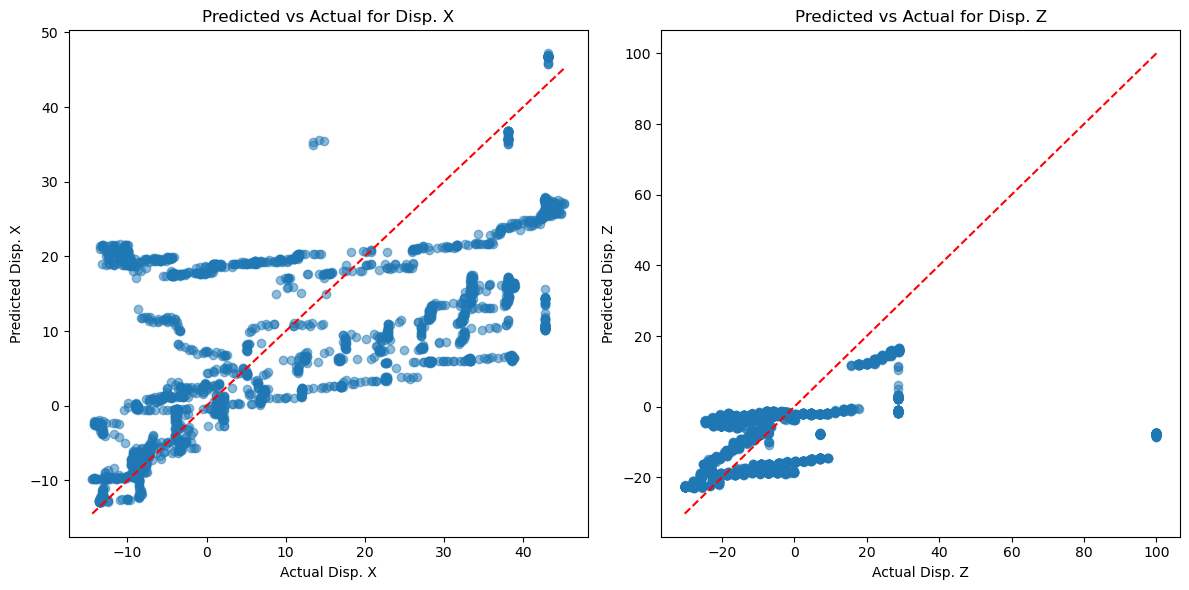

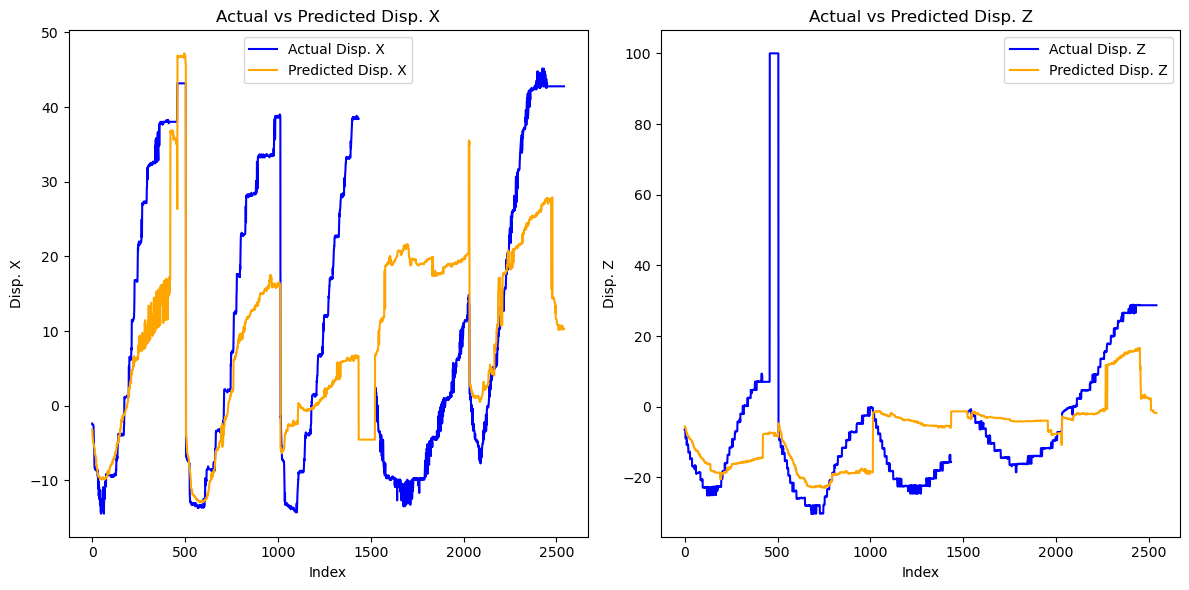

No path specified. Models will be saved in: "AutogluonModels\ag-20250819_094914"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.3.0
Python Version:     3.12.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          20
Memory Avail:       10.94 GB / 31.72 GB (34.5%)
Disk Space Avail:   250.08 GB / 930.07 GB (26.9%)
Presets specified: ['best_quality']
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluon will be fit on subsets of the data. Then holdo

RMSE for Disp. X: 14.8136715611127
RMSE for Disp. Z: 8.827062559141321
MSE for Disp. X: 219.44486512051918
MSE for Disp. Z: 77.91703342299452
RMSE for Disp. X + Z: 17.244184484733214


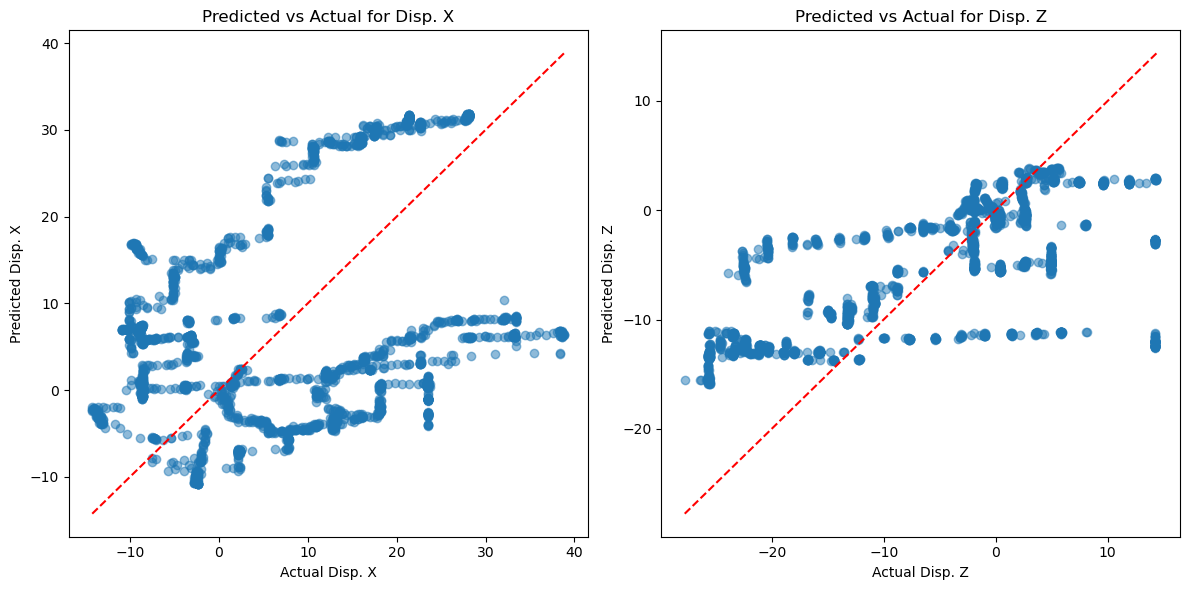

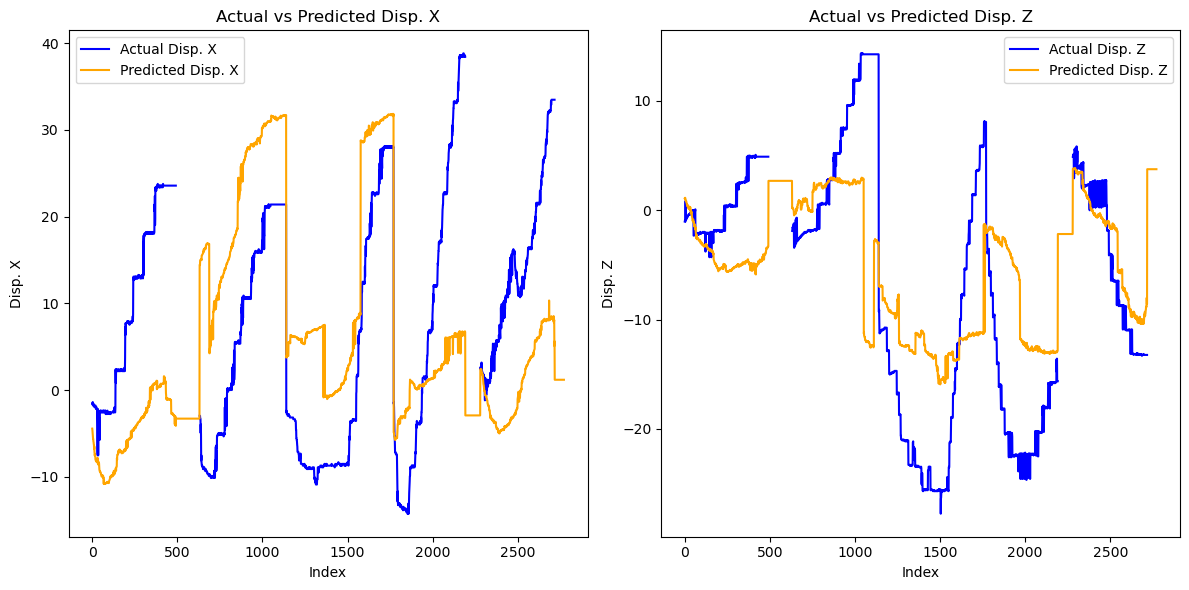

No path specified. Models will be saved in: "AutogluonModels\ag-20250819_095953"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.3.0
Python Version:     3.12.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          20
Memory Avail:       10.94 GB / 31.72 GB (34.5%)
Disk Space Avail:   247.82 GB / 930.07 GB (26.6%)
Presets specified: ['best_quality']
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluon will be fit on subsets of the data. Then holdo

RMSE for Disp. X: 15.663239562992677
RMSE for Disp. Z: 10.259239460887839
MSE for Disp. X: 245.337073607699
MSE for Disp. Z: 105.25199431583819
RMSE for Disp. X + Z: 18.724023817639658


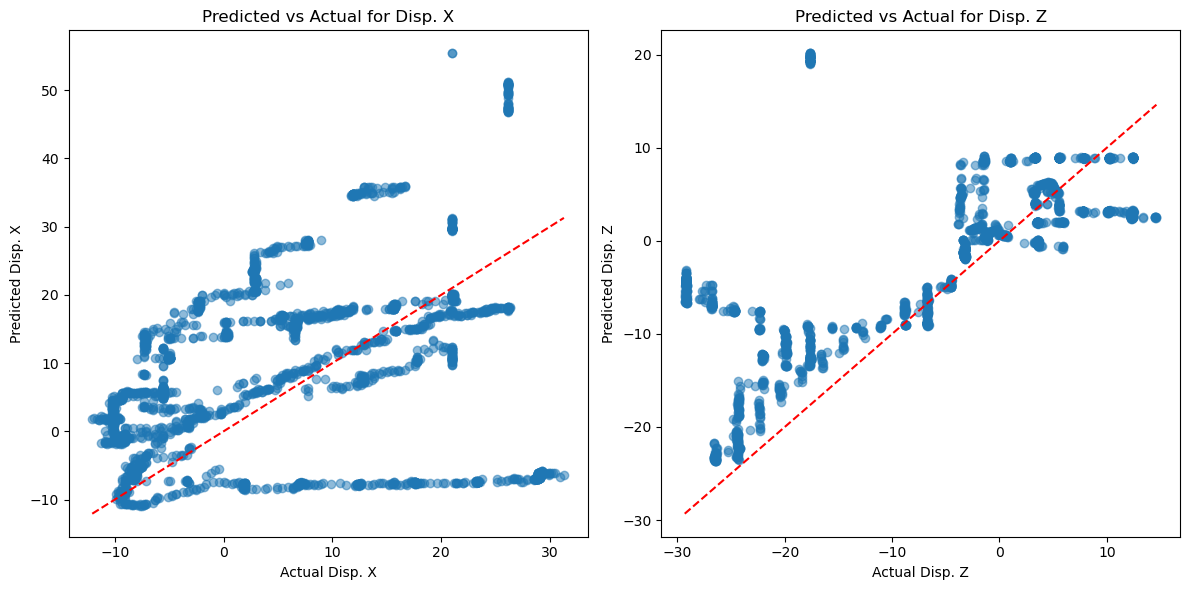

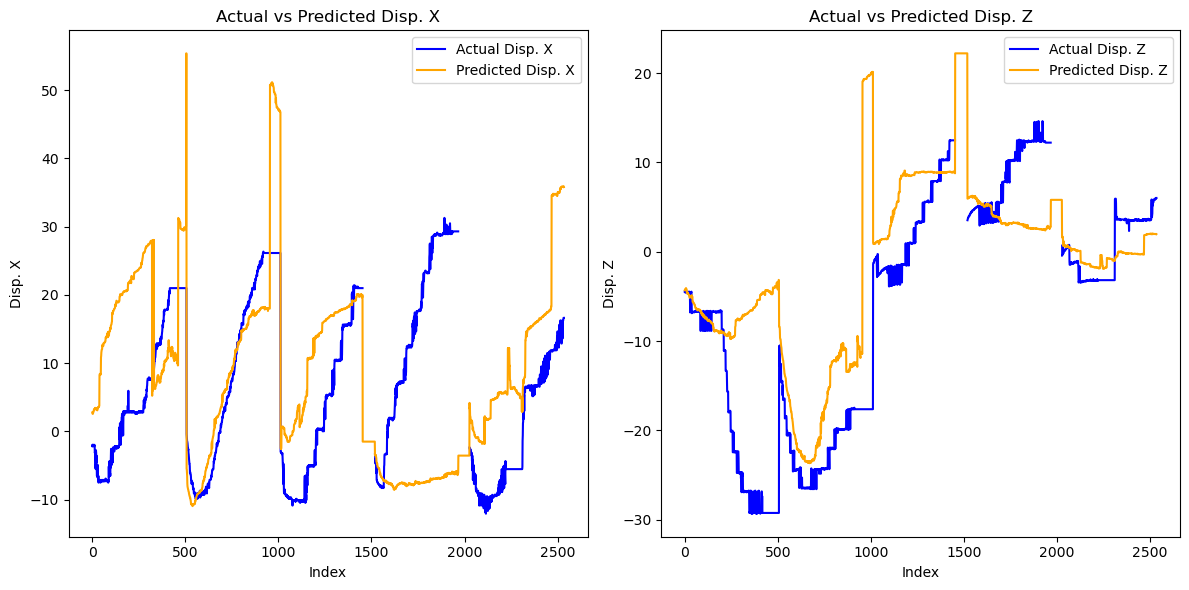

No path specified. Models will be saved in: "AutogluonModels\ag-20250819_101027"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.3.0
Python Version:     3.12.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          20
Memory Avail:       11.34 GB / 31.72 GB (35.8%)
Disk Space Avail:   245.76 GB / 930.07 GB (26.4%)
Presets specified: ['best_quality']
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluon will be fit on subsets of the data. Then holdo

RMSE for Disp. X: 9.447700309352893
RMSE for Disp. Z: 6.7779661788931636
MSE for Disp. X: 89.25904113534673
MSE for Disp. Z: 45.94082552221959
RMSE for Disp. X + Z: 11.627547749098532


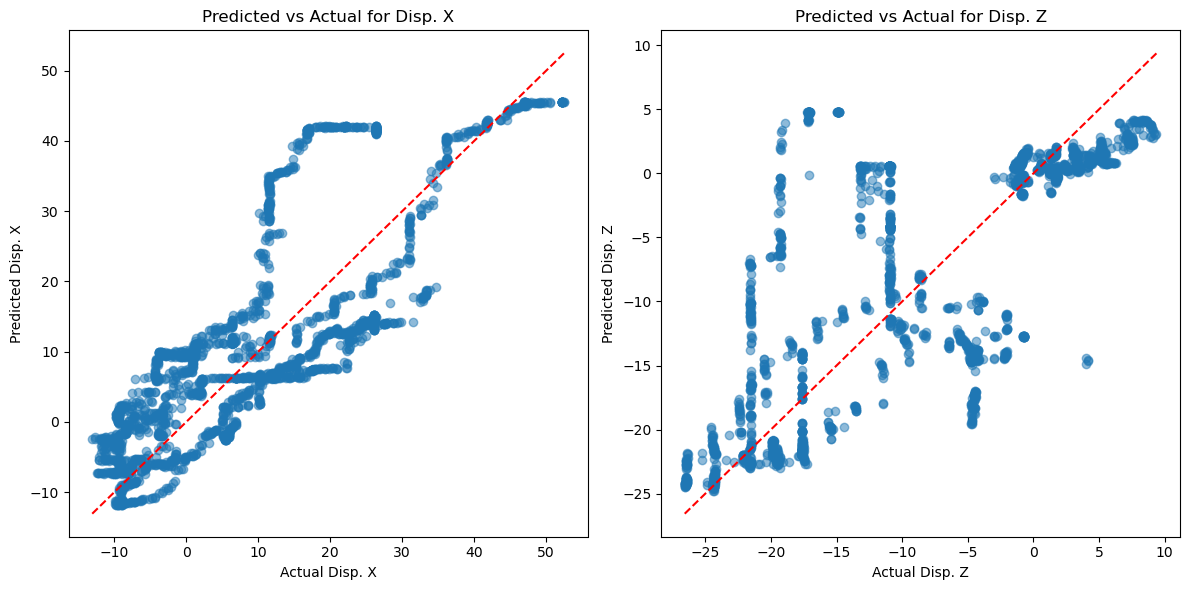

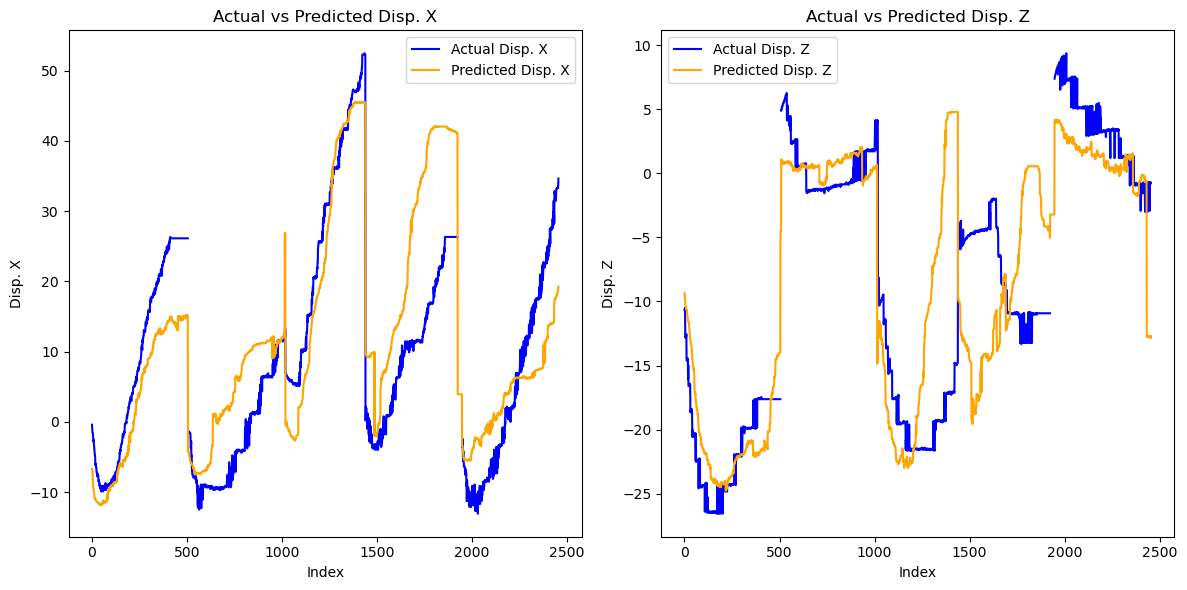

No path specified. Models will be saved in: "AutogluonModels\ag-20250819_102131"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.3.0
Python Version:     3.12.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          20
Memory Avail:       11.34 GB / 31.72 GB (35.7%)
Disk Space Avail:   243.46 GB / 930.07 GB (26.2%)
Presets specified: ['best_quality']
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluon will be fit on subsets of the data. Then holdo

RMSE for Disp. X: 19.790604389854416
RMSE for Disp. Z: 12.95866964473319
MSE for Disp. X: 391.6680221157249
MSE for Disp. Z: 167.9271189613294
RMSE for Disp. X + Z: 23.65576337971477


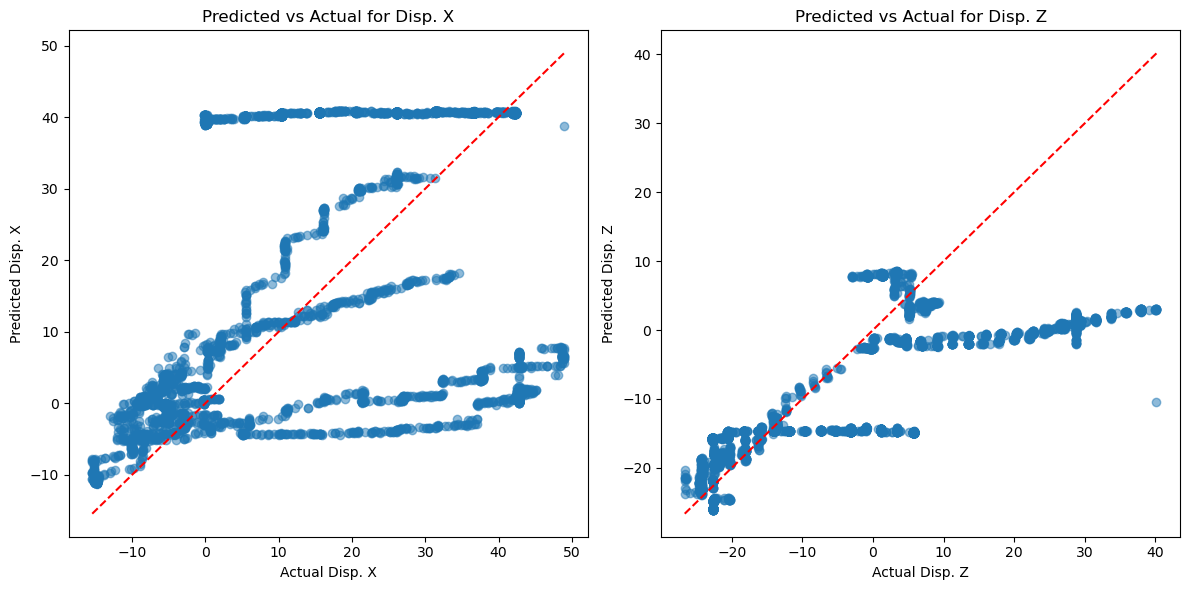

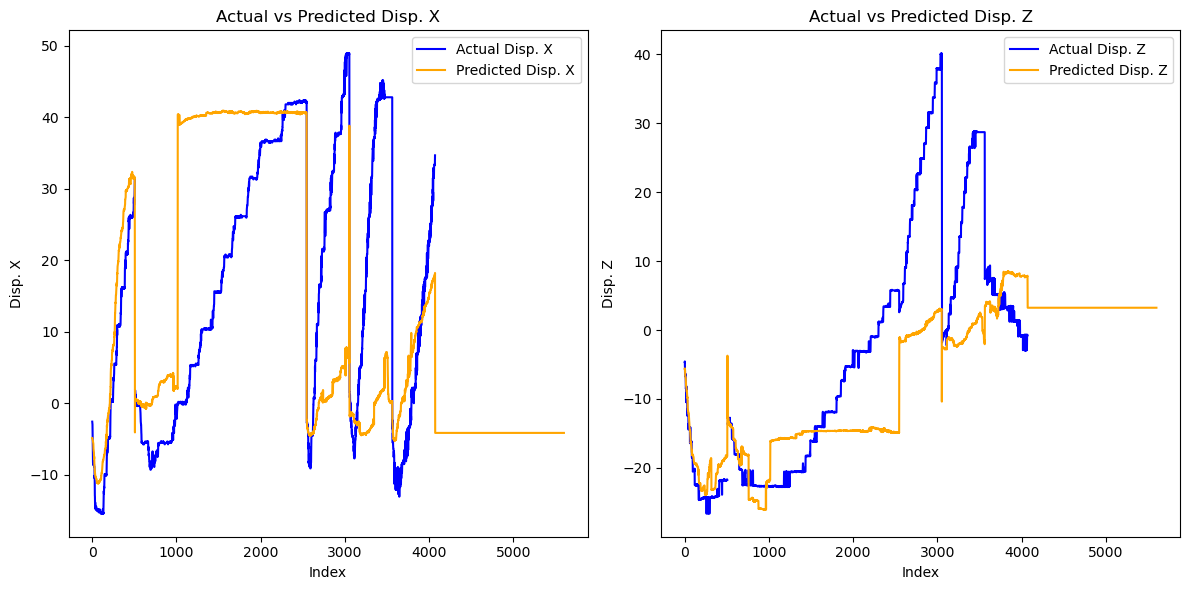

No path specified. Models will be saved in: "AutogluonModels\ag-20250819_103206"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.3.0
Python Version:     3.12.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          20
Memory Avail:       11.08 GB / 31.72 GB (34.9%)
Disk Space Avail:   243.45 GB / 930.07 GB (26.2%)
Presets specified: ['best_quality']
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluon will be fit on subsets of the data. Then holdo

RMSE for Disp. X: 16.5518994462526
RMSE for Disp. Z: 20.094555570371856
MSE for Disp. X: 273.96537527885715
MSE for Disp. Z: 403.7911635707626
RMSE for Disp. X + Z: 26.033757678245756


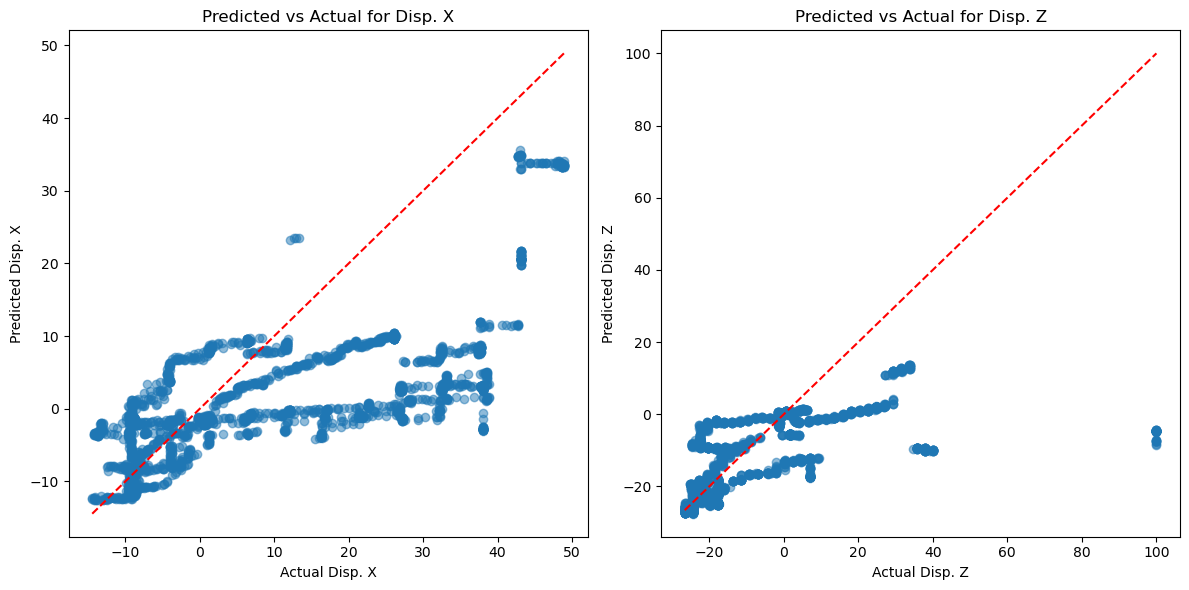

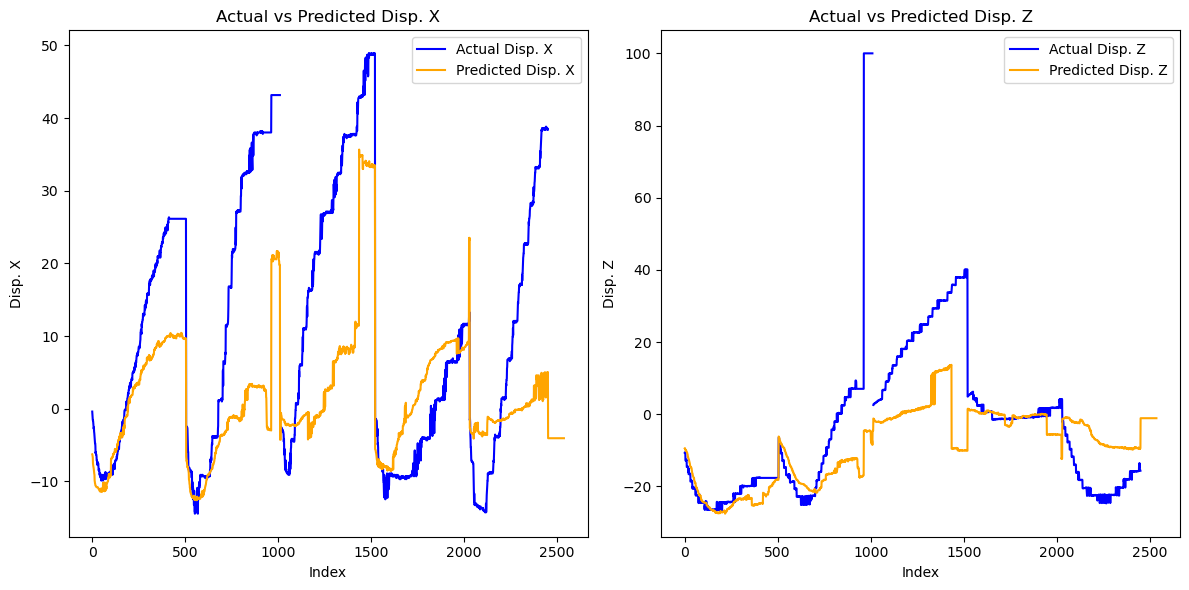

No path specified. Models will be saved in: "AutogluonModels\ag-20250819_104244"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.3.0
Python Version:     3.12.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          20
Memory Avail:       11.17 GB / 31.72 GB (35.2%)
Disk Space Avail:   241.46 GB / 930.07 GB (26.0%)
Presets specified: ['best_quality']
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluon will be fit on subsets of the data. Then holdo

RMSE for Disp. X: 11.188960498281237
RMSE for Disp. Z: 7.640386296383135
MSE for Disp. X: 125.19283703209788
MSE for Disp. Z: 58.375502757959204
RMSE for Disp. X + Z: 13.548739417010612


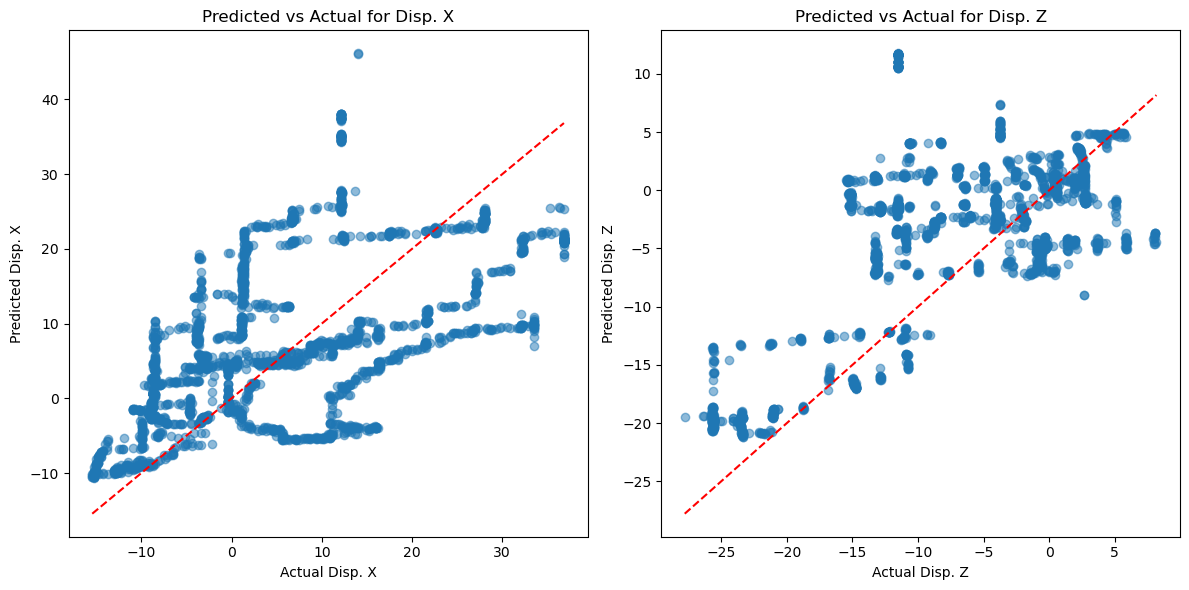

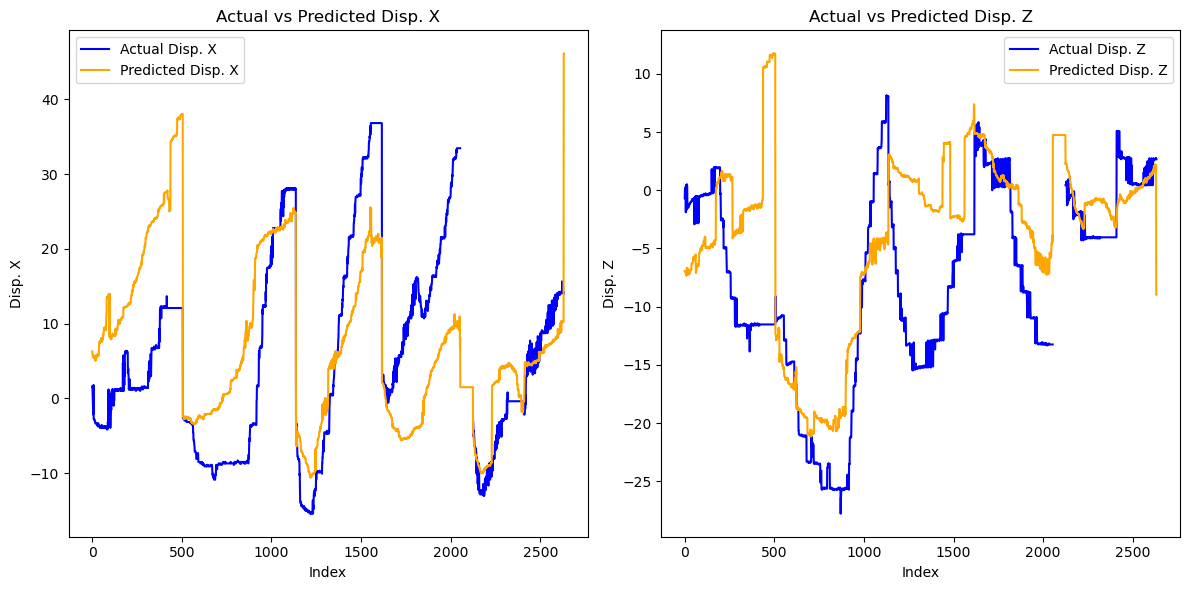

No path specified. Models will be saved in: "AutogluonModels\ag-20250819_105325"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.3.0
Python Version:     3.12.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          20
Memory Avail:       10.93 GB / 31.72 GB (34.5%)
Disk Space Avail:   239.47 GB / 930.07 GB (25.7%)
Presets specified: ['best_quality']
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluon will be fit on subsets of the data. Then holdo

RMSE for Disp. X: 12.972966624588125
RMSE for Disp. Z: 11.683076901332035
MSE for Disp. X: 168.2978630426774
MSE for Disp. Z: 136.49428588243813
RMSE for Disp. X + Z: 17.458297423434953


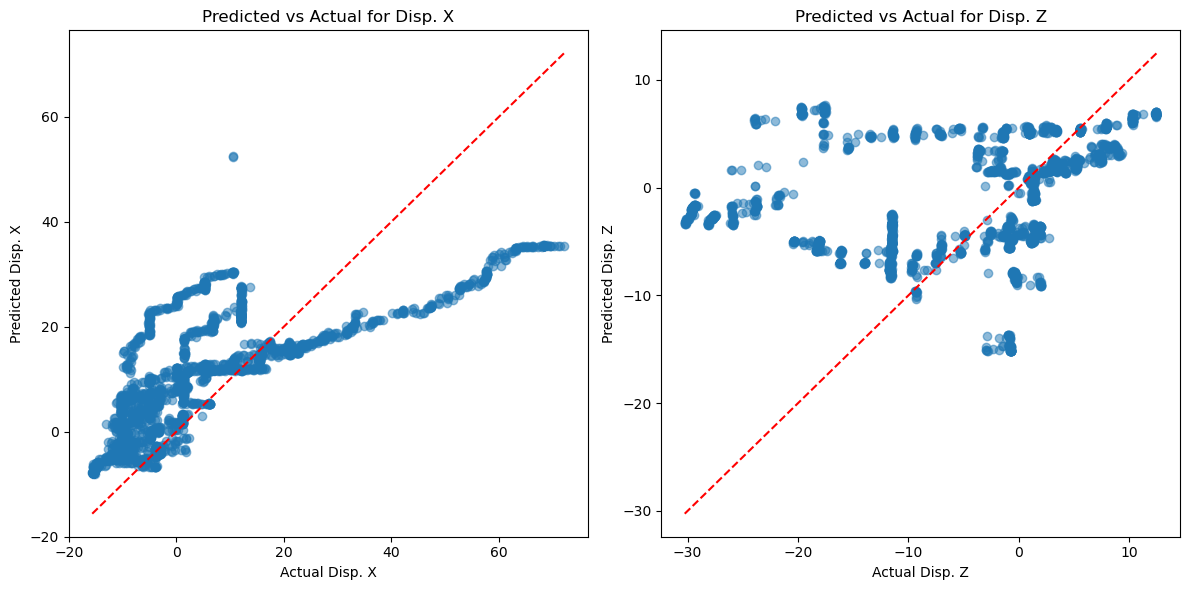

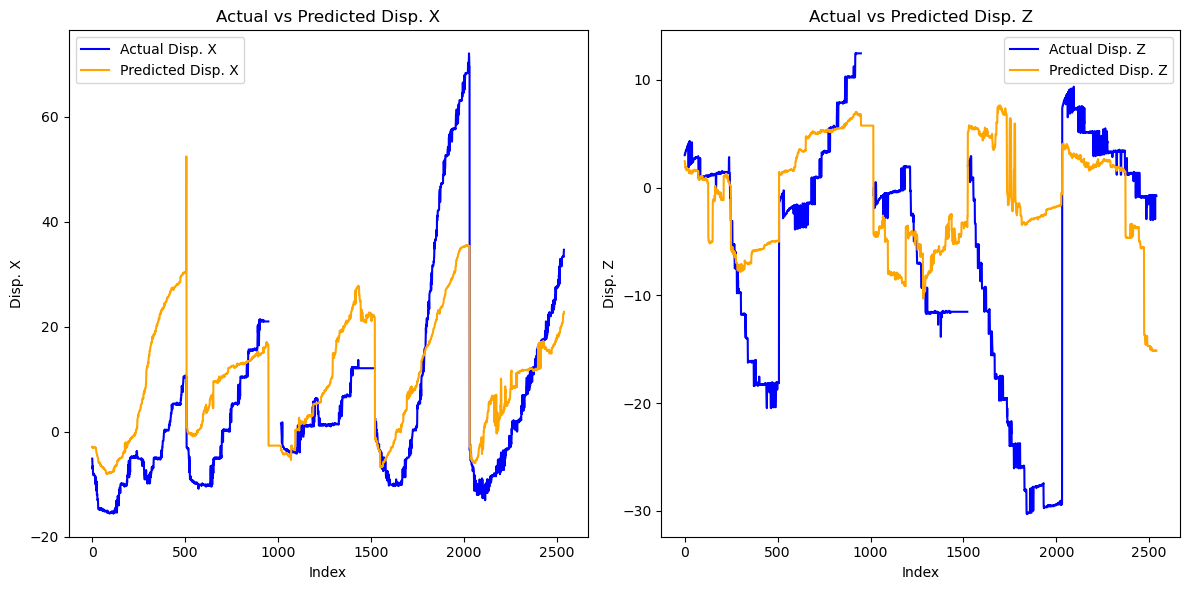

No path specified. Models will be saved in: "AutogluonModels\ag-20250819_110356"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.3.0
Python Version:     3.12.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          20
Memory Avail:       10.71 GB / 31.72 GB (33.8%)
Disk Space Avail:   237.52 GB / 930.07 GB (25.5%)
Presets specified: ['best_quality']
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluon will be fit on subsets of the data. Then holdo

RMSE for Disp. X: 12.9716091584318
RMSE for Disp. Z: 11.671171036371993
MSE for Disp. X: 168.26264415911177
MSE for Disp. Z: 136.21623336024848
RMSE for Disp. X + Z: 17.449323124962763


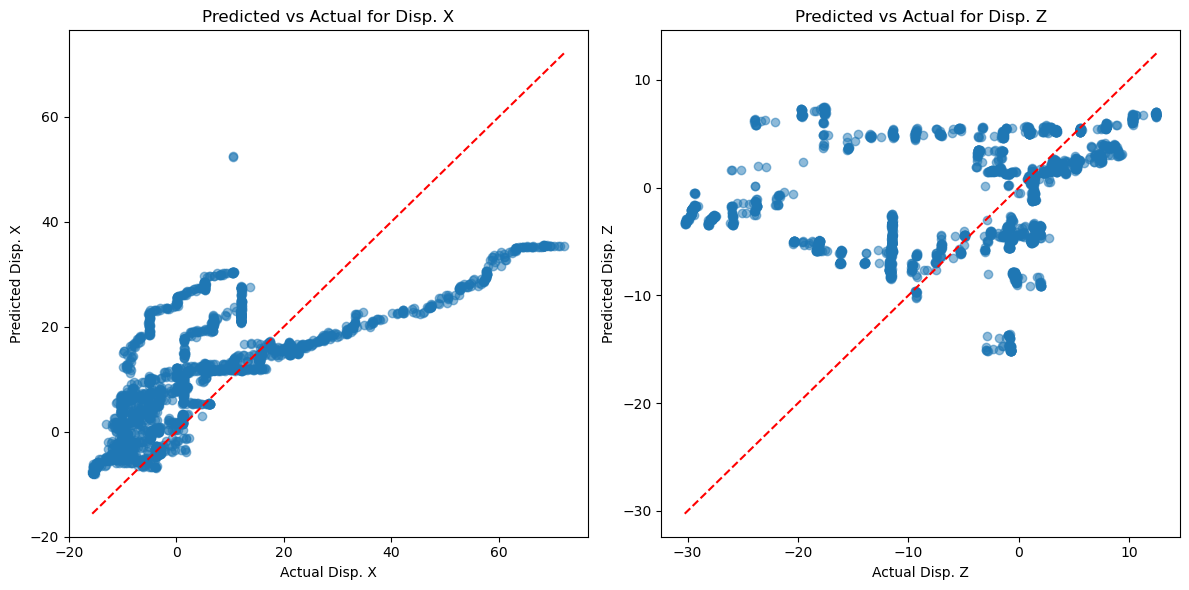

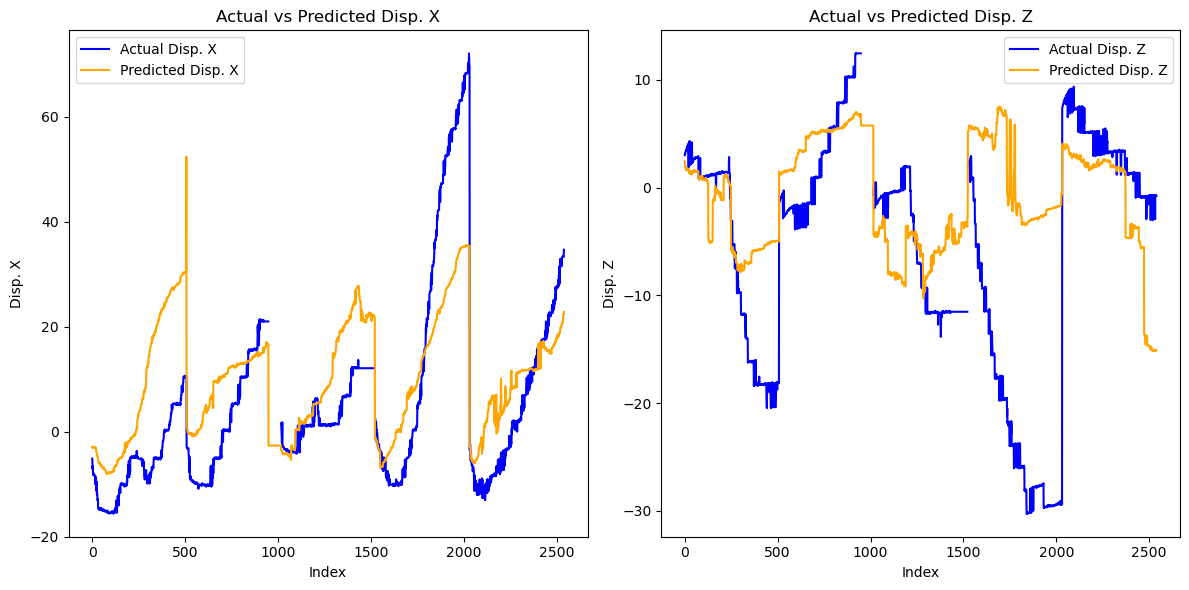

Average RMSE for Disp. X: 14.614921946101841, Std: 2.8586391238977438
Average RMSE for Disp. Z: 11.757978899188789, Std: 4.289200402791601
Average MSE for Disp. X: 221.7677611313281, Std: 83.11037551604178
Average MSE for Disp. Z: 156.64730788907647, Std: 118.23557654026162
Average RMSE for Disp. X + Z: 19.452893589911103, Std: 14.189642421720972


In [27]:
'''
holdout_experiments
    |_experiment_seed{42~51}
        |_train_set.csv
        |_holdout_set.csv
'''
folder_path = rf'C:\Users\E4-159\Documents\py_surr\imbd2025\初\holdout_experiments'
# 遍歷資料夾中的所有子資料夾
x_pred = []
z_pred = []
mse_x_list = []
mse_z_list = []
rmse_x_list = []
rmse_z_list = []

for subdir, dirs, files in os.walk(folder_path):
    for dir_name in dirs:
        train_path = os.path.join(subdir, dir_name, 'train_set.csv')
        holdout_path = os.path.join(subdir, dir_name, 'holdout_set.csv')
        
        # 訓練模型
        predictor_x, predictor_z = train(train_path,t=300)
        
        # 預測
        holdout_data = pd.read_csv(holdout_path)
        preds_x, preds_z, mse_x, mse_z, rmse_x, rmse_z = predict(predictor_x, predictor_z, holdout_data)
        x_pred.append(preds_x)
        z_pred.append(preds_z)
        mse_x_list.append(mse_x)
        mse_z_list.append(mse_z)
        rmse_x_list.append(rmse_x)
        rmse_z_list.append(rmse_z)

# print results
print(f"Average RMSE for Disp. X: {np.mean(rmse_x_list)}, Std: {np.std(rmse_x_list)}")
print(f"Average RMSE for Disp. Z: {np.mean(rmse_z_list)}, Std: {np.std(rmse_z_list)}")
print(f"Average MSE for Disp. X: {np.mean(mse_x_list)}, Std: {np.std(mse_x_list)}")
print(f"Average MSE for Disp. Z: {np.mean(mse_z_list)}, Std: {np.std(mse_z_list)}")
print(f"Average RMSE for Disp. X + Z: {((np.mean(mse_x_list) + np.mean(mse_z_list)) ** 0.5)}, Std: {((np.std(mse_x_list) + np.std(mse_z_list)) ** 0.5)}")
        
        
